In [15]:
2+2

4

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler
import xarray as xr
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

## Comparing a RANS field with a log and a uniform field

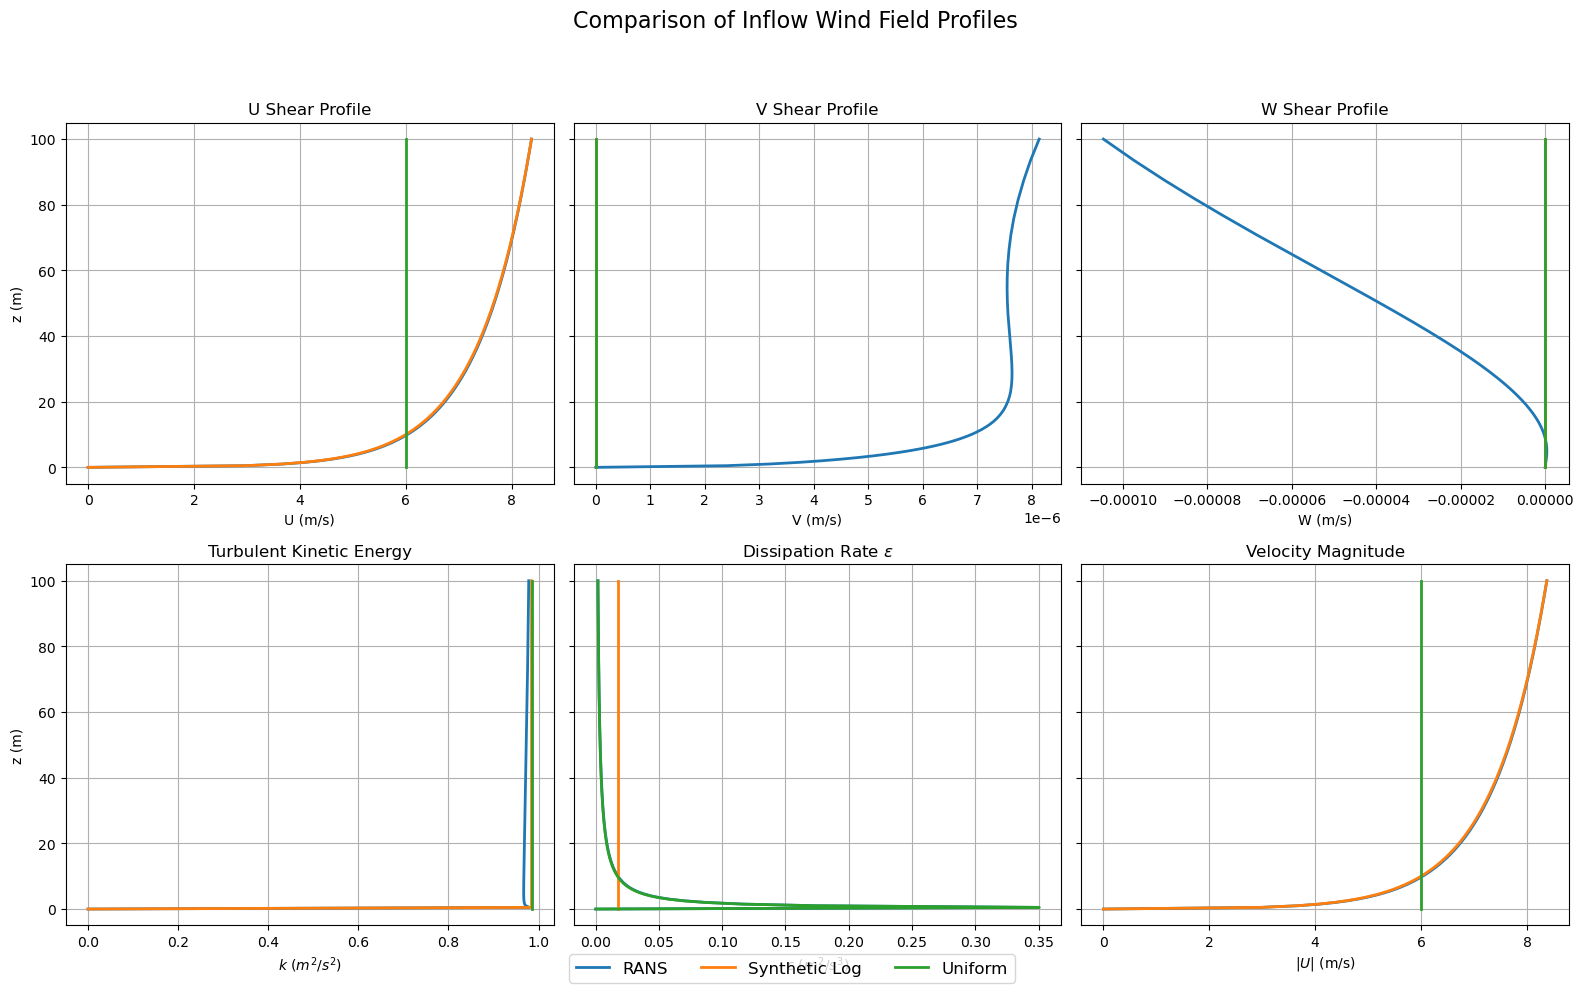

In [17]:
# Rans file and standard conditions
filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
U_ref = 6    # [m/s]
z0 = 0.03   # [m]
wd = 0      # [deg]

# --- Wind field definitions ---
rw = WindField(profile='rans', ds=filepath,U_ref=U_ref)
lw = WindField(profile='log', U_ref=U_ref, z0=z0, direction=wd)
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

point = np.array([100,100]) #x,y coords for the point of interest

point = np.array([100,100]) #x,y coords for the point of interest
z_vals = np.linspace(0.0001, 100, 200)

urw = np.zeros(len(z_vals))
vrw = np.zeros(len(z_vals))
wrw = np.zeros(len(z_vals))
krw = np.zeros(len(z_vals))
erw = np.zeros(len(z_vals))

ulw = np.zeros(len(z_vals))
vlw = np.zeros(len(z_vals))
wlw = np.zeros(len(z_vals))
klw = np.zeros(len(z_vals))
elw = np.zeros(len(z_vals))

uuw = np.zeros(len(z_vals))
vuw = np.zeros(len(z_vals))
wuw = np.zeros(len(z_vals))
kuw = np.zeros(len(z_vals))
euw = np.zeros(len(z_vals))

for i, z in enumerate(z_vals):

    # --- RANS ---
    vel, krw[i], erw[i] = rw.get_profile_at(x=point[0], y=point[1], z=z)
    urw[i], vrw[i], wrw[i] = vel

    # --- Synthetic Log ---
    vel, klw[i], elw[i] = lw.get_profile_at(x=point[0], y=point[1], z=z)
    ulw[i], vlw[i], wlw[i] = vel

    # --- Uniform ---
    vel, kuw[i], euw[i] = uw.get_profile_at(x=point[0], y=point[1], z=z)
    uuw[i], vuw[i], wuw[i] = vel

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

# ===== First Row =====
# U shear
axs[0,0].plot(urw, z_vals, linewidth=2, label='RANS')
axs[0,0].plot(ulw, z_vals, linewidth=2, label='Synthetic Log')
axs[0,0].plot(uuw, z_vals, linewidth=2, label='Uniform')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_title('U Shear Profile')
axs[0,0].grid(True)

# V shear
axs[0,1].plot(vrw, z_vals, linewidth=2)
axs[0,1].plot(vlw, z_vals, linewidth=2)
axs[0,1].plot(vuw, z_vals, linewidth=2)
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_title('V Shear Profile')

axs[0,1].grid(True)

# W shear
axs[0,2].plot(wrw, z_vals, linewidth=2)
axs[0,2].plot(wlw, z_vals, linewidth=2)
axs[0,2].plot(wuw, z_vals, linewidth=2)
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_title('W Shear Profile')
axs[0,2].grid(True)


# ===== Second Row =====
# TKE

axs[1,0].plot(krw, z_vals, linewidth=2)
axs[1,0].plot(klw, z_vals, linewidth=2)
axs[1,0].plot(kuw, z_vals, linewidth=2)
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')
axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].grid(True)

# epsilon
axs[1,1].plot(elw, z_vals, linewidth=2)
axs[1,1].plot(euw, z_vals, linewidth=2)
axs[1,1].plot(erw, z_vals, linewidth=2)
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')
axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].grid(True)

# Velocity magnitude panel (nice use of 6th slot)
Umag_rw = np.sqrt(urw**2 + vrw**2 + wrw**2)
Umag_lw = np.sqrt(ulw**2 + vlw**2 + wlw**2)
Umag_uw = np.sqrt(uuw**2 + vuw**2 + wuw**2)

axs[1,2].plot(Umag_rw, z_vals, linewidth=2)
axs[1,2].plot(Umag_lw, z_vals, linewidth=2)
axs[1,2].plot(Umag_uw, z_vals, linewidth=2)
axs[1,2].set_xlabel(r'$|U|$ (m/s)')
axs[1,2].set_title('Velocity Magnitude')
axs[1,2].grid(True)

# Global legend
fig.legend(['RANS', 'Synthetic Log', 'Uniform'],
           loc='lower center',
           ncol=3,
           fontsize=12,
           frameon=True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.94])
plt.show()

## Comparing wind fields for the different roughness simulations

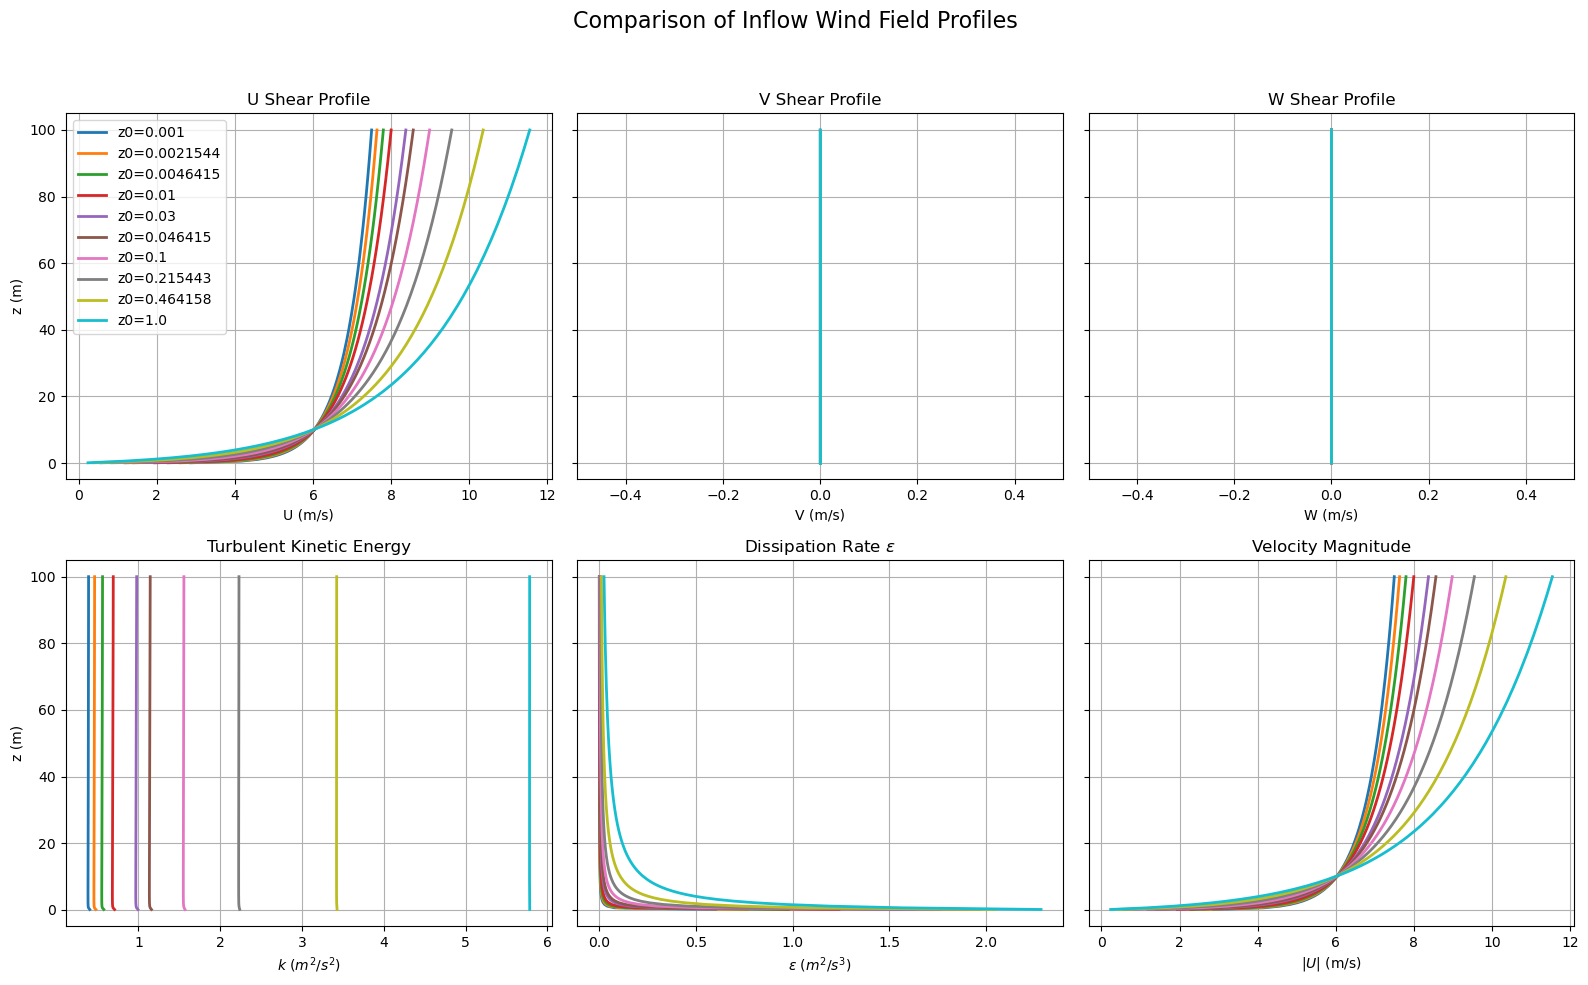

In [28]:
# Plot showing u wind components for uniform, and different z0 values
# filepaths for RANS simulations with varying z0
datafile01 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.001_mb_cartesian.nc'
datafile02 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0021_mb_cartesian.nc'
datafile03 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0046_mb_cartesian.nc'
datafile04 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.01_mb_cartesian.nc'
datafile05 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
datafile06 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.046_mb_cartesian.nc'
datafile07 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.1_mb_cartesian.nc'
datafile08 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.21_mb_cartesian.nc'
datafile09 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.46_mb_cartesian.nc'
datafile10 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_1_mb_cartesian.nc'

U_ref = 6      # [m/s]
wd = 0         # [deg]

# ---------------------------------------------------
# Uniform field
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

# ---------------------------------------------------
# RANS wind fields
wf_library_z0 = {
    0.001:    WindField(profile='rans', ds=datafile01, U_ref=U_ref),
    0.0021544:WindField(profile='rans', ds=datafile02, U_ref=U_ref),
    0.0046415:WindField(profile='rans', ds=datafile03, U_ref=U_ref),
    0.01:     WindField(profile='rans', ds=datafile04, U_ref=U_ref),
    0.03:     WindField(profile='rans', ds=datafile05, U_ref=U_ref),
    0.046415: WindField(profile='rans', ds=datafile06, U_ref=U_ref),
    0.1:      WindField(profile='rans', ds=datafile07, U_ref=U_ref),
    0.215443: WindField(profile='rans', ds=datafile08, U_ref=U_ref),
    0.464158: WindField(profile='rans', ds=datafile09, U_ref=U_ref),
    1.0:      WindField(profile='rans', ds=datafile10, U_ref=U_ref)
}

# ---------------------------------------------------
point = np.array([100, 0])   # x,y coordinates
z_vals = np.linspace(0.1, 100, 200)

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

for z0, wf_current in wf_library_z0.items():

    # Allocate arrays ONCE per wind field
    uwf = np.zeros(len(z_vals))
    vwf = np.zeros(len(z_vals))
    wwf = np.zeros(len(z_vals))
    kwf = np.zeros(len(z_vals))
    ewf = np.zeros(len(z_vals))

    # Fill arrays
    for i, z in enumerate(z_vals):

        vel, kwf[i], ewf[i] = wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )

        uwf[i], vwf[i], wwf[i] = vel

    # Velocity magnitude
    Umag = np.sqrt(uwf**2 + vwf**2 + wwf**2)

    # =================================================
    # First row

    # U profile
    axs[0,0].plot(uwf, z_vals, linewidth=2, label=f'z0={z0}')

    # V profile
    axs[0,1].plot(vwf, z_vals, linewidth=2)

    # W profile
    axs[0,2].plot(wwf, z_vals, linewidth=2)

    # =================================================
    # Second row

    # TKE
    axs[1,0].plot(kwf, z_vals, linewidth=2)

    # Dissipation
    axs[1,1].plot(ewf, z_vals, linewidth=2)

    # Velocity magnitude
    axs[1,2].plot(Umag, z_vals, linewidth=2)

# ---------------------------------------------------
# Labels and formatting

axs[0,0].set_title('U Shear Profile')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].legend()

axs[0,1].set_title('V Shear Profile')
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_xlim(-0.5, 0.5)

axs[0,2].set_title('W Shear Profile')
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_xlim(-0.5, 0.5)

axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')

axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')

axs[1,2].set_title('Velocity Magnitude')
axs[1,2].set_xlabel(r'$|U|$ (m/s)')

# Grid on all plots
for ax in axs.flat:
    ax.grid(True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

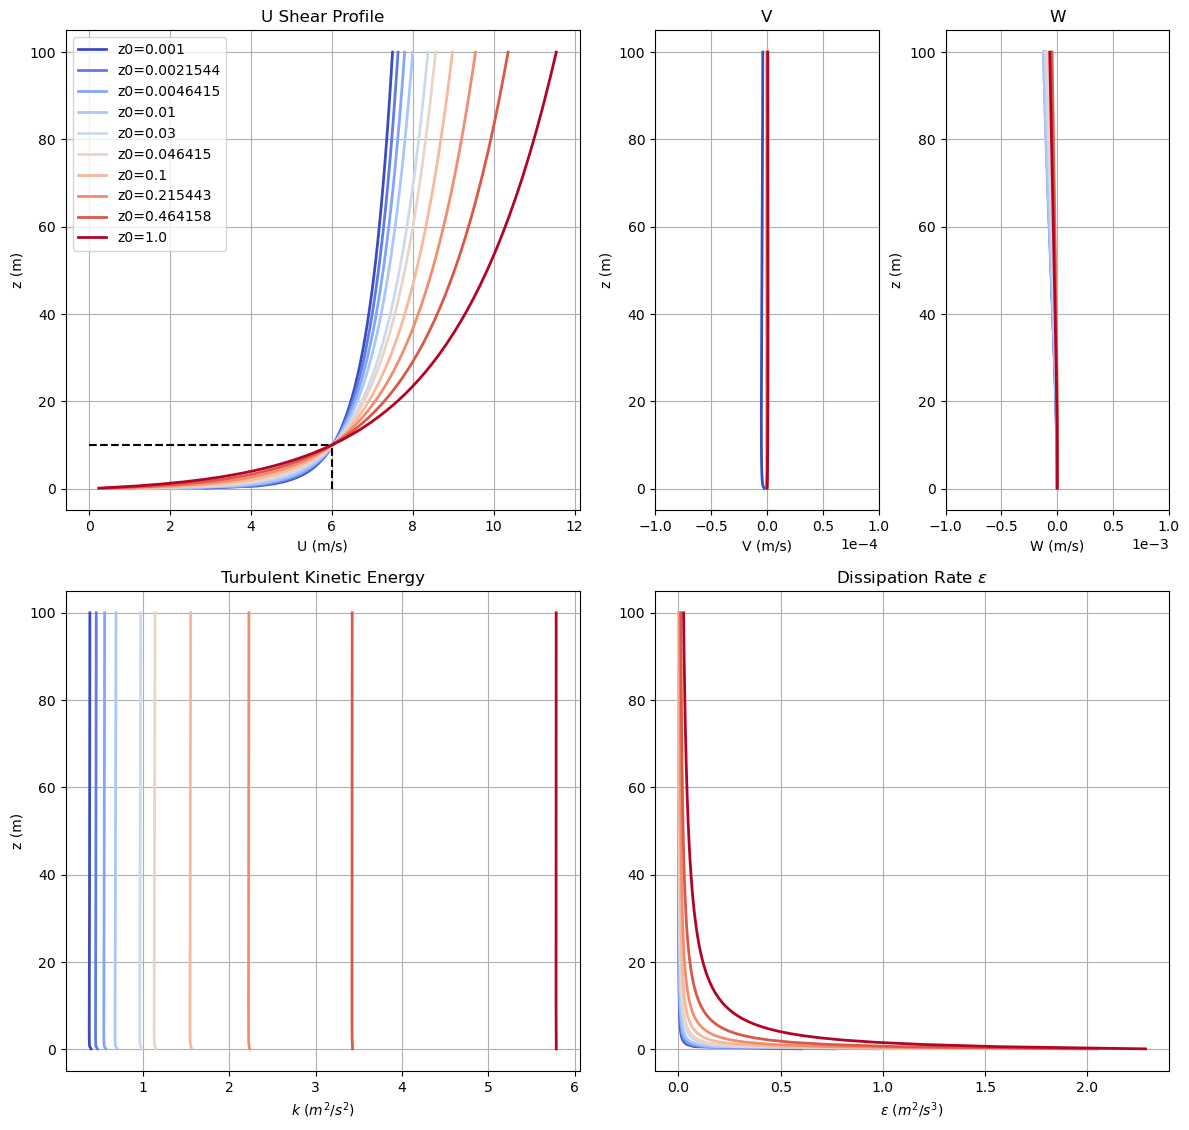

In [82]:
# Plot showing u wind components for uniform, and different z0 values
# filepaths for RANS simulations with varying z0
datafile01 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.001_mb_cartesian.nc'
datafile02 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0021_mb_cartesian.nc'
datafile03 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0046_mb_cartesian.nc'
datafile04 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.01_mb_cartesian.nc'
datafile05 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
datafile06 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.046_mb_cartesian.nc'
datafile07 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.1_mb_cartesian.nc'
datafile08 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.21_mb_cartesian.nc'
datafile09 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.46_mb_cartesian.nc'
datafile10 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_1_mb_cartesian.nc'

U_ref = 6      # [m/s]
wd = 0         # [deg]

# ---------------------------------------------------
# Uniform field
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

# ---------------------------------------------------
# RANS wind fields
wf_library_z0 = {
    0.001:    WindField(profile='rans', ds=datafile01, U_ref=U_ref),
    0.0021544:WindField(profile='rans', ds=datafile02, U_ref=U_ref),
    0.0046415:WindField(profile='rans', ds=datafile03, U_ref=U_ref),
    0.01:     WindField(profile='rans', ds=datafile04, U_ref=U_ref),
    0.03:     WindField(profile='rans', ds=datafile05, U_ref=U_ref),
    0.046415: WindField(profile='rans', ds=datafile06, U_ref=U_ref),
    0.1:      WindField(profile='rans', ds=datafile07, U_ref=U_ref),
    0.215443: WindField(profile='rans', ds=datafile08, U_ref=U_ref),
    0.464158: WindField(profile='rans', ds=datafile09, U_ref=U_ref),
    1.0:      WindField(profile='rans', ds=datafile10, U_ref=U_ref)
}

# ---------------------------------------------------
point = np.array([100, 0])   # x,y coordinates
z_vals = np.linspace(0.1, 100, 200)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(wf_library_z0)))
# ---------------------------------------------------

fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Left column
ax_u = fig.add_subplot(gs[0, 0])
ax_k = fig.add_subplot(gs[1, 0], sharey=ax_u)

# Bottom-right
ax_eps = fig.add_subplot(gs[1, 1], sharey=ax_u)

# Split top-right into TWO COLUMNS
gs_right = gs[0, 1].subgridspec(1, 2, wspace=0.3)

ax_v = fig.add_subplot(gs_right[0], sharey=ax_u)
ax_w = fig.add_subplot(gs_right[1], sharey=ax_u)
ax_v.set_xlim(-1e-4, 1e-4)
ax_v.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax_w.set_xlim(-1e-3, 1e-3)
ax_w.ticklabel_format(style='sci', axis='x', scilimits=(0,0))


for z0, wf_current in wf_library_z0.items():

    # Allocate arrays ONCE per wind field
    uwf = np.zeros(len(z_vals))
    vwf = np.zeros(len(z_vals))
    wwf = np.zeros(len(z_vals))
    kwf = np.zeros(len(z_vals))
    ewf = np.zeros(len(z_vals))

    # Fill arrays
    for i, z in enumerate(z_vals):

        vel, kwf[i], ewf[i] = wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )

        uwf[i], vwf[i], wwf[i] = vel

    # Velocity magnitude
    Umag = np.sqrt(uwf**2 + vwf**2 + wwf**2)

    # =================================================
    # First row
    # U profile
    ax_u.plot(uwf, z_vals, linewidth=2, label=f'z0={z0}',color=colors[list(wf_library_z0.keys()).index(z0)])

    # V profile
    ax_v.plot(vwf, z_vals, linewidth=2, color=colors[list(wf_library_z0.keys()).index(z0)])

    # W profile
    ax_w.plot(wwf, z_vals, linewidth=2, color=colors[list(wf_library_z0.keys()).index(z0)])

    # TKE
    ax_k.plot(kwf, z_vals, linewidth=2, color=colors[list(wf_library_z0.keys()).index(z0)])

    # Dissipation
    ax_eps.plot(ewf, z_vals, linewidth=2, color=colors[list(wf_library_z0.keys()).index(z0)])
# ---------------------------------------------------
# Labels and formatting

ax_u.plot([0, U_ref], [10, 10], color='k', linestyle='--')
ax_u.plot([U_ref, U_ref], [0,10], color='k', linestyle='--')

ax_u.set_title('U Shear Profile')
ax_u.set_xlabel('U (m/s)')
ax_u.set_ylabel('z (m)')
ax_u.legend()

ax_v.set_title('V')
ax_v.set_xlabel('V (m/s)')
ax_v.set_ylabel('z (m)')

ax_w.set_title('W')
ax_w.set_xlabel('W (m/s)')
ax_w.set_ylabel('z (m)')

ax_k.set_title('Turbulent Kinetic Energy')
ax_k.set_xlabel(r'$k$ ($m^2/s^2$)')
ax_k.set_ylabel('z (m)')

ax_eps.set_title(r'Dissipation Rate $\varepsilon$')
ax_eps.set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')

for ax in [ax_u, ax_v, ax_w, ax_k, ax_eps]:
    ax.grid(True)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

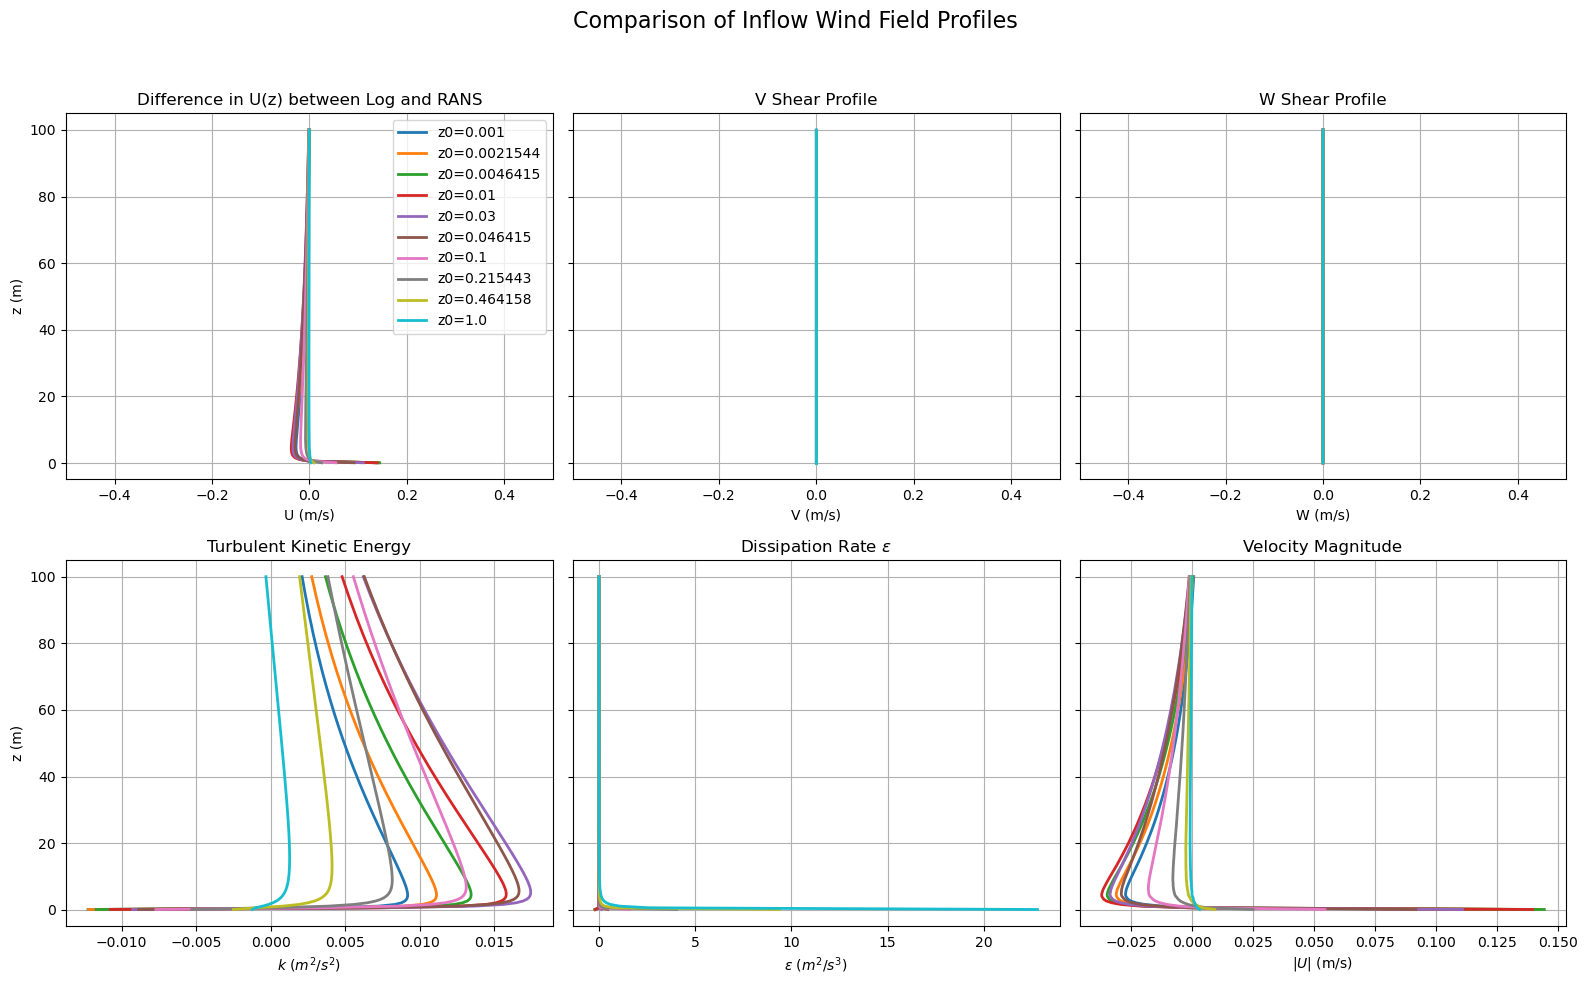

In [19]:
### Difference between rans and log profiles for different z0 values

U_ref = 6      # [m/s]
wd = 0         # [deg]

# ---------------------------------------------------
# Uniform field
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

# ---------------------------------------------------
# RANS wind fields
wf_library_z0 = {
    0.001:    WindField(profile='rans', ds=datafile01, U_ref=U_ref),
    0.0021544:WindField(profile='rans', ds=datafile02, U_ref=U_ref),
    0.0046415:WindField(profile='rans', ds=datafile03, U_ref=U_ref),
    0.01:     WindField(profile='rans', ds=datafile04, U_ref=U_ref),
    0.03:     WindField(profile='rans', ds=datafile05, U_ref=U_ref),
    0.046415: WindField(profile='rans', ds=datafile06, U_ref=U_ref),
    0.1:      WindField(profile='rans', ds=datafile07, U_ref=U_ref),
    0.215443: WindField(profile='rans', ds=datafile08, U_ref=U_ref),
    0.464158: WindField(profile='rans', ds=datafile09, U_ref=U_ref),
    1.0:      WindField(profile='rans', ds=datafile10, U_ref=U_ref)
}

wf_library_list = list(wf_library_z0.values())

# ---------------------------------------------------
point = np.array([100, 0])   # x,y coordinates
z_vals = np.linspace(0.1, 100, 200)

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

for z0, wf_current in wf_library_z0.items():

    # Allocate arrays ONCE per wind field
    uwf = np.zeros(len(z_vals))
    vwf = np.zeros(len(z_vals))
    wwf = np.zeros(len(z_vals))
    kwf = np.zeros(len(z_vals))
    ewf = np.zeros(len(z_vals))

    # Allocate arrays ONCE per wind field
    syn_uwf = np.zeros(len(z_vals))
    syn_vwf = np.zeros(len(z_vals))
    syn_wwf = np.zeros(len(z_vals))
    syn_kwf = np.zeros(len(z_vals))
    syn_ewf = np.zeros(len(z_vals))

    syn_wf_current = WindField(profile='log', U_ref=U_ref, z0=z0, direction=wd)

    # Fill arrays
    for i, z in enumerate(z_vals):

        vel, kwf[i], ewf[i] = wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )
        uwf[i], vwf[i], wwf[i] = vel
        syn_vel, syn_kwf[i], syn_ewf[i] = syn_wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )
        syn_uwf[i], syn_vwf[i], syn_wwf[i] = syn_vel

    # Velocity magnitude
    Umag = np.sqrt(uwf**2 + vwf**2 + wwf**2)
    syn_Umag = np.sqrt(syn_uwf**2 + syn_vwf**2 + syn_wwf**2)

    # =================================================
    # First row

    # U profile
    axs[0,0].plot(syn_uwf-uwf, z_vals, linewidth=2, label=f'z0={z0}')

    # V profile
    axs[0,1].plot(syn_vwf-vwf, z_vals, linewidth=2)

    # W profile
    axs[0,2].plot(syn_wwf-wwf, z_vals, linewidth=2)

    # =================================================
    # Second row

    # TKE
    axs[1,0].plot(syn_kwf-kwf, z_vals, linewidth=2)

    # Dissipation
    axs[1,1].plot(syn_ewf-ewf, z_vals, linewidth=2)

    # Velocity magnitude
    axs[1,2].plot(syn_Umag-Umag, z_vals, linewidth=2)

# ---------------------------------------------------
# Labels and formatting

axs[0,0].set_title('Difference in U(z) between Log and RANS')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_xlim(-0.5, 0.5)

axs[0,0].legend()

axs[0,1].set_title('V Shear Profile')
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_xlim(-0.5, 0.5)

axs[0,2].set_title('W Shear Profile')
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_xlim(-0.5, 0.5)

axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')

axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')

axs[1,2].set_title('Velocity Magnitude')
axs[1,2].set_xlabel(r'$|U|$ (m/s)')

# Grid on all plots
for ax in axs.flat:
    ax.grid(True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

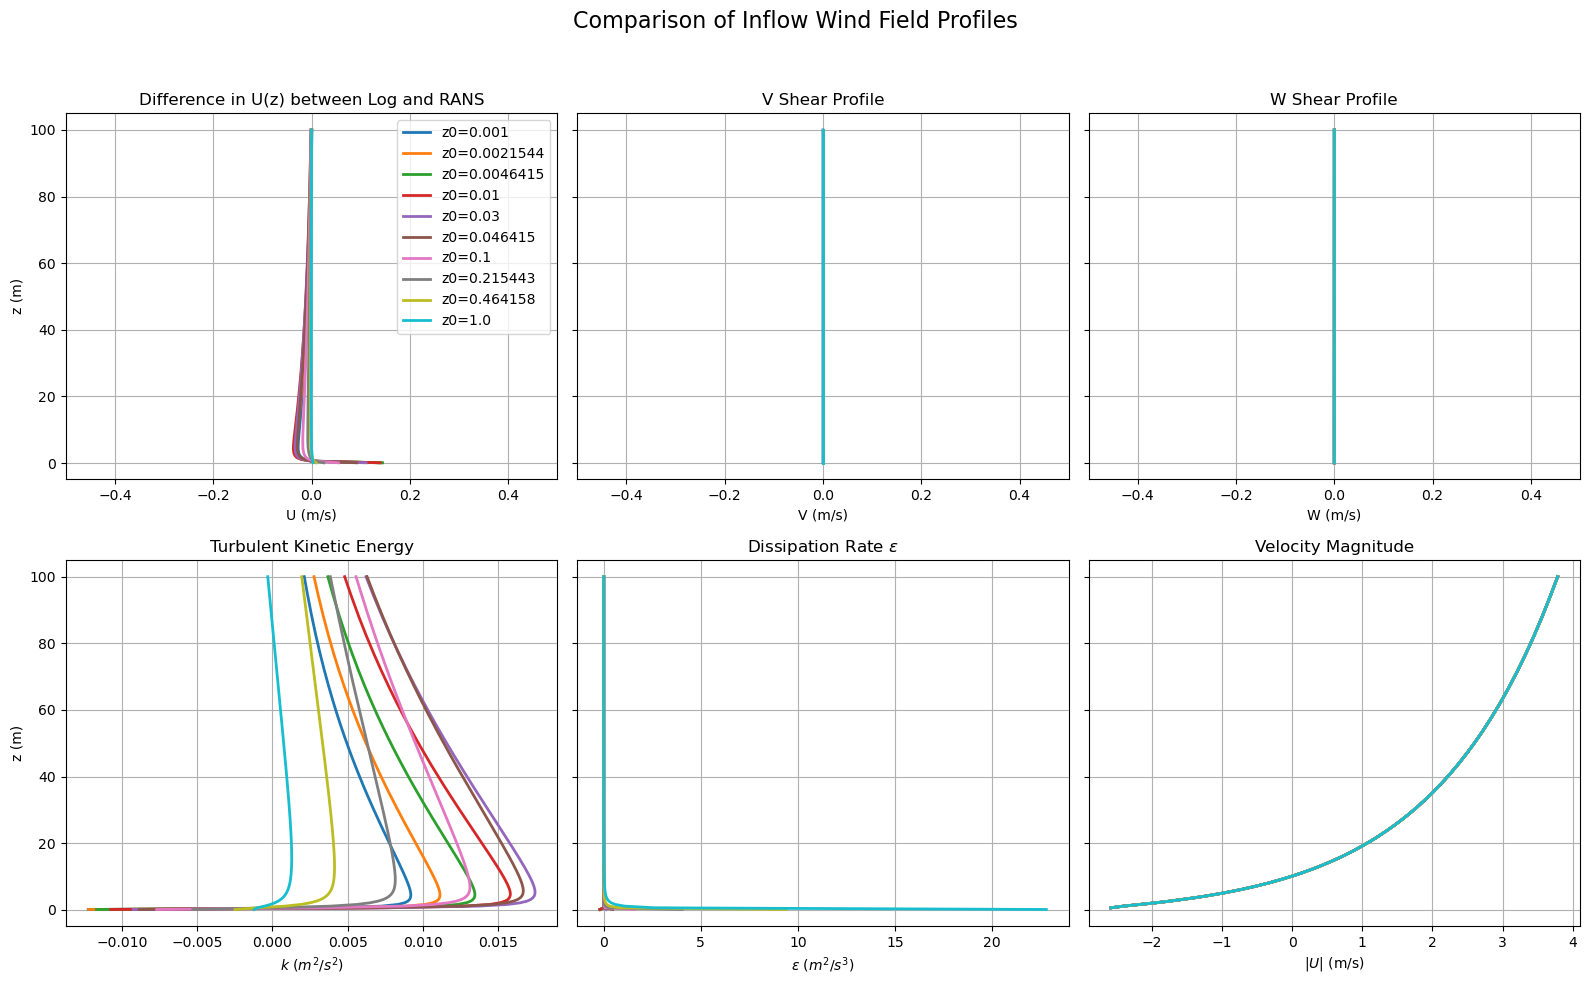

In [26]:
### Difference between rans and log profiles for different z0 values

U_ref = 6      # [m/s]
wd = 0         # [deg]

# ---------------------------------------------------
# Uniform field
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

# ---------------------------------------------------
# RANS wind fields
wf_library_z0 = {
    0.001:    WindField(profile='rans', ds=datafile01, U_ref=U_ref),
    0.0021544:WindField(profile='rans', ds=datafile02, U_ref=U_ref),
    0.0046415:WindField(profile='rans', ds=datafile03, U_ref=U_ref),
    0.01:     WindField(profile='rans', ds=datafile04, U_ref=U_ref),
    0.03:     WindField(profile='rans', ds=datafile05, U_ref=U_ref),
    0.046415: WindField(profile='rans', ds=datafile06, U_ref=U_ref),
    0.1:      WindField(profile='rans', ds=datafile07, U_ref=U_ref),
    0.215443: WindField(profile='rans', ds=datafile08, U_ref=U_ref),
    0.464158: WindField(profile='rans', ds=datafile09, U_ref=U_ref),
    1.0:      WindField(profile='rans', ds=datafile10, U_ref=U_ref)
}

wf_library_list = list(wf_library_z0.values())

# ---------------------------------------------------
point = np.array([100, 0])   # x,y coordinates
z_vals = np.linspace(0.1, 100, 200)

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

for z0, wf_current in wf_library_z0.items():

    # Allocate arrays ONCE per wind field
    uwf = np.zeros(len(z_vals))
    vwf = np.zeros(len(z_vals))
    wwf = np.zeros(len(z_vals))
    kwf = np.zeros(len(z_vals))
    ewf = np.zeros(len(z_vals))

    # Allocate arrays ONCE per wind field
    syn_uwf = np.zeros(len(z_vals))
    syn_vwf = np.zeros(len(z_vals))
    syn_wwf = np.zeros(len(z_vals))
    syn_kwf = np.zeros(len(z_vals))
    syn_ewf = np.zeros(len(z_vals))

    syn_wf_current = WindField(profile='log', U_ref=U_ref, z0=z0, direction=wd)

    # Fill arrays
    for i, z in enumerate(z_vals):

        vel, kwf[i], ewf[i] = wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )
        uwf[i], vwf[i], wwf[i] = vel
        syn_vel, syn_kwf[i], syn_ewf[i] = syn_wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )
        syn_uwf[i], syn_vwf[i], syn_wwf[i] = syn_vel


    # =================================================
    # First row

    # U profile
    axs[0,0].plot(syn_uwf-uwf, z_vals, linewidth=2, label=f'z0={z0}')

    # V profile
    axs[0,1].plot(syn_vwf-vwf, z_vals, linewidth=2)

    # W profile
    axs[0,2].plot(syn_wwf-wwf, z_vals, linewidth=2)

    # =================================================
    # Second row

    # TKE
    axs[1,0].plot(syn_kwf-kwf, z_vals, linewidth=2)

    # Dissipation
    axs[1,1].plot(syn_ewf-ewf, z_vals, linewidth=2)

    # Velocity magnitude
    axs[1,2].plot(syn_Umag-Umag, z_vals, linewidth=2)

# ---------------------------------------------------
# Labels and formatting

axs[0,0].set_title('Difference in U(z) between Log and RANS')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_xlim(-0.5, 0.5)

axs[0,0].legend()

axs[0,1].set_title('V Shear Profile')
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_xlim(-0.5, 0.5)

axs[0,2].set_title('W Shear Profile')
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_xlim(-0.5, 0.5)

axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')

axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')

axs[1,2].set_title('Velocity Magnitude')
axs[1,2].set_xlabel(r'$|U|$ (m/s)')

# Grid on all plots
for ax in axs.flat:
    ax.grid(True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

## Comparing wind fields for grid fidelity simulations

### Comparing wind fields xy fidelity

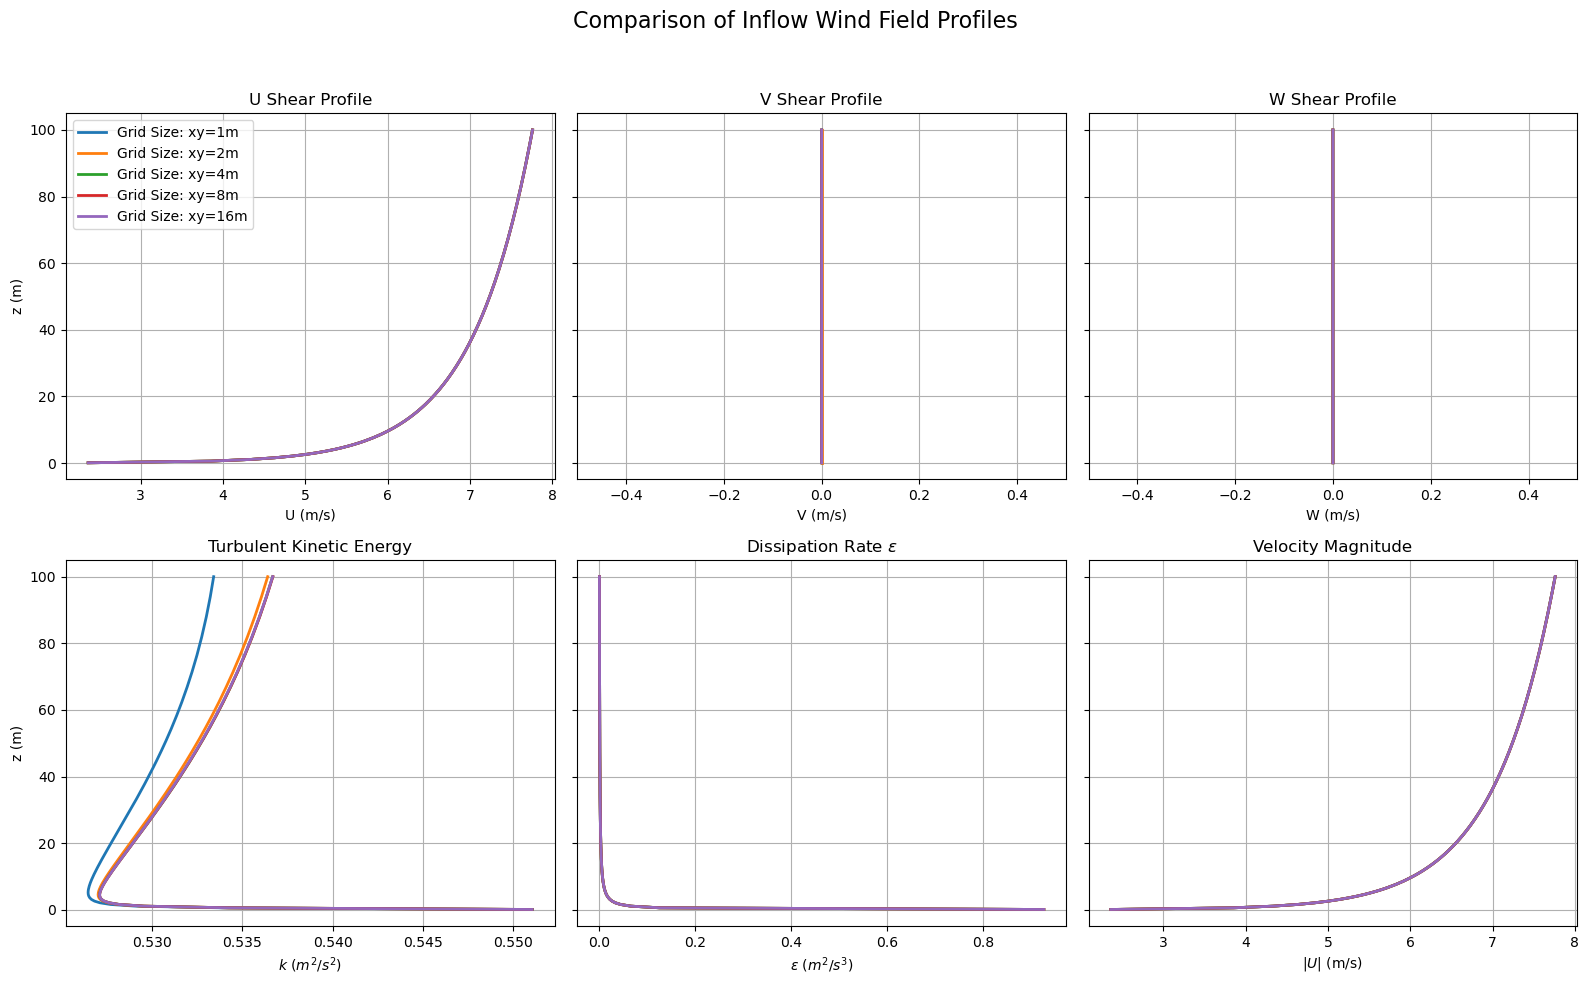

In [20]:
# xy grid test 
filexy1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy1m_mb_cartesian.nc'
filexy2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy2m_mb_cartesian.nc'
filexy4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy4m_mb_cartesian.nc'
filexy8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy8m_mb_cartesian.nc'
filexy16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy16m_mb_cartesian.nc'

U_ref = 6      # [m/s]
wd = 0         # [deg]

files = {
    'xy=1m': filexy1m,
    'xy=2m': filexy2m,
    'xy=4m': filexy4m,
    'xy=8m': filexy8m,
    'xy=16m': filexy16m,
}

wf_library_grid = {
    'xy=1m': WindField(profile='rans', ds=files['xy=1m'], U_ref=U_ref),
    'xy=2m': WindField(profile='rans', ds=files['xy=2m'], U_ref=U_ref),
    'xy=4m': WindField(profile='rans', ds=files['xy=4m'], U_ref=U_ref),
    'xy=8m': WindField(profile='rans', ds=files['xy=8m'], U_ref=U_ref),
    'xy=16m': WindField(profile='rans', ds=files['xy=16m'], U_ref=U_ref)
}

# ---------------------------------------------------
# Uniform field
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

# ---------------------------------------------------
point = np.array([0, 0])   # x,y coordinates
z_vals = np.linspace(0.1, 100, 200)

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

for grid_size, wf_current in wf_library_grid.items():

    # Allocate arrays ONCE per wind field
    uwf = np.zeros(len(z_vals))
    vwf = np.zeros(len(z_vals))
    wwf = np.zeros(len(z_vals))
    kwf = np.zeros(len(z_vals))
    ewf = np.zeros(len(z_vals))

    # Fill arrays
    for i, z in enumerate(z_vals):

        vel, kwf[i], ewf[i] = wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )

        uwf[i], vwf[i], wwf[i] = vel

    # Velocity magnitude
    Umag = np.sqrt(uwf**2 + vwf**2 + wwf**2)

    # =================================================
    # First row

    # U profile
    axs[0,0].plot(uwf, z_vals, linewidth=2, label=f'Grid Size: {grid_size}')

    # V profile
    axs[0,1].plot(vwf, z_vals, linewidth=2)

    # W profile
    axs[0,2].plot(wwf, z_vals, linewidth=2)

    # =================================================
    # Second row

    # TKE
    axs[1,0].plot(kwf, z_vals, linewidth=2)

    # Dissipation
    axs[1,1].plot(ewf, z_vals, linewidth=2)

    # Velocity magnitude
    axs[1,2].plot(Umag, z_vals, linewidth=2)

# ---------------------------------------------------
# Labels and formatting

axs[0,0].set_title('U Shear Profile')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].legend()

axs[0,1].set_title('V Shear Profile')
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_xlim(-0.5, 0.5)

axs[0,2].set_title('W Shear Profile')
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_xlim(-0.5, 0.5)

axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')

axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')

axs[1,2].set_title('Velocity Magnitude')
axs[1,2].set_xlabel(r'$|U|$ (m/s)')

# Grid on all plots
for ax in axs.flat:
    ax.grid(True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

### Comparing wind fields z fidelity

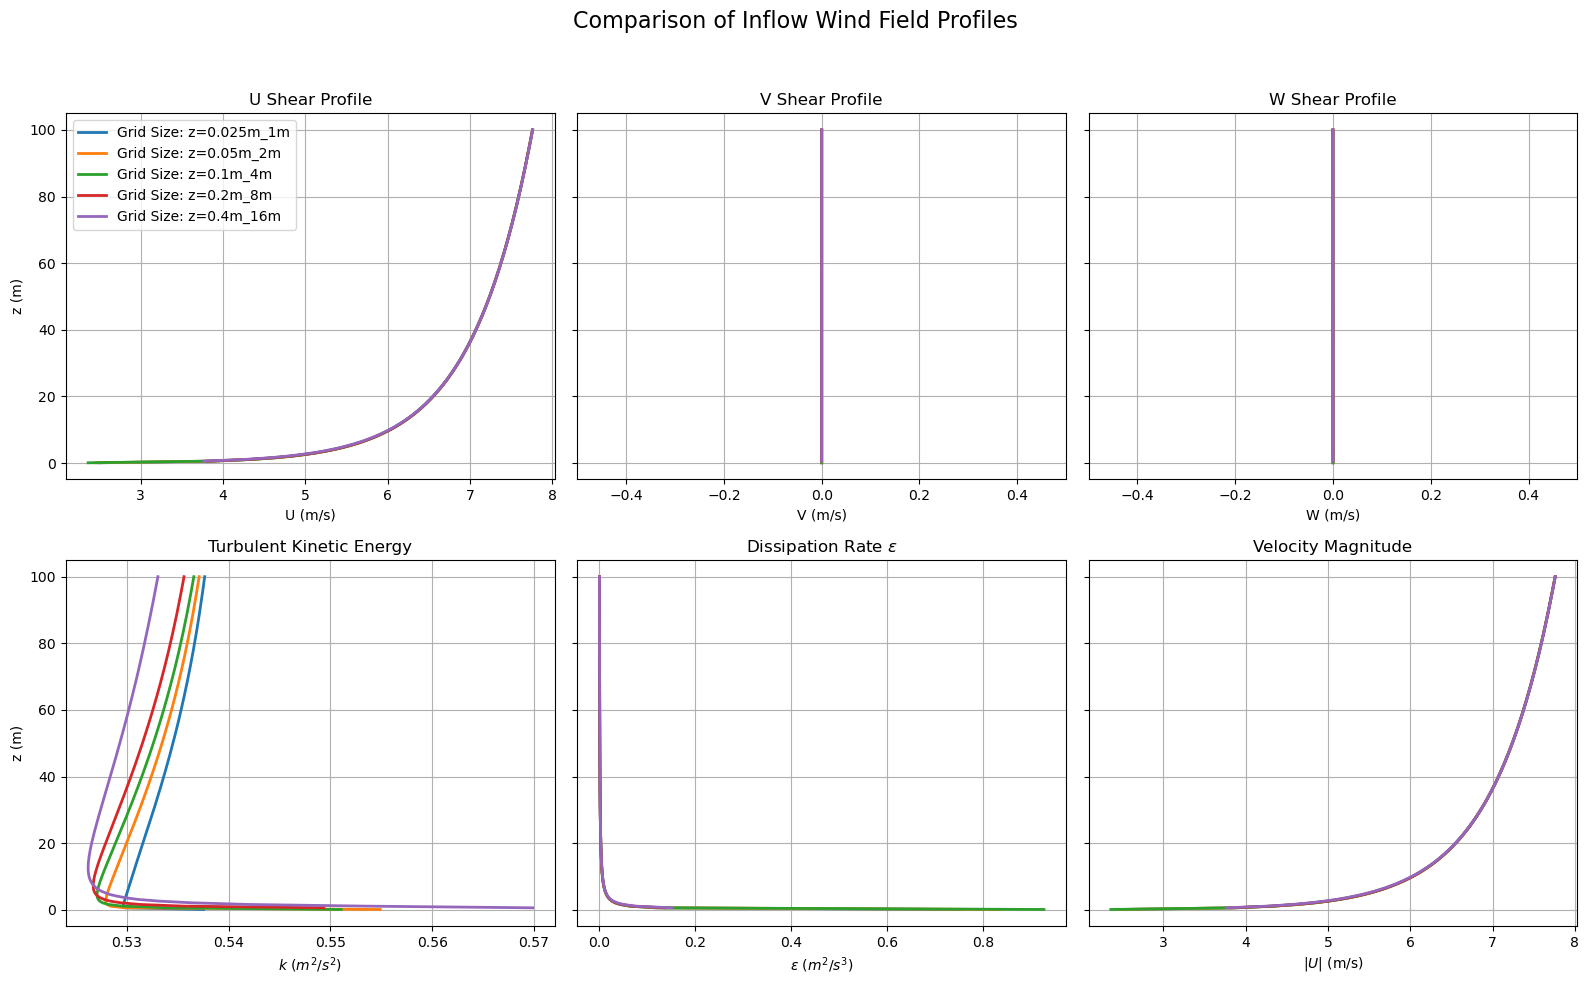

In [21]:
# z grid test
filez1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0025m_1m_mb_cartesian.nc'
filez2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
filez4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z01m_4m_cartesian.nc'
filez8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z02m_8m_mb_cartesian.nc'
filez16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z04m_16m_mb_cartesian.nc'

U_ref = 6      # [m/s]
wd = 0         # [deg]

files = {
    'z=0.025m_1m' : filez1m,
    'z=0.05m_2m' : filez2m,
    'z=0.1m_4m' : filez4m,
    'z=0.2m_8m' : filez8m,
    'z=0.4m_16m' : filez16m
}

wf_library_grid = {
    'z=0.025m_1m' : WindField(profile='rans', ds=files['z=0.025m_1m'], U_ref=U_ref),
    'z=0.05m_2m' : WindField(profile='rans', ds=files['z=0.05m_2m'], U_ref=U_ref),
    'z=0.1m_4m' : WindField(profile='rans', ds=files['z=0.1m_4m'], U_ref=U_ref),
    'z=0.2m_8m' : WindField(profile='rans', ds=files['z=0.2m_8m'], U_ref=U_ref),
    'z=0.4m_16m' : WindField(profile='rans', ds=files['z=0.4m_16m'], U_ref=U_ref)
}

# ---------------------------------------------------
# Uniform field
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

# ---------------------------------------------------
point = np.array([100, 100])   # x,y coordinates
z_vals = np.linspace(0.1, 100, 200)

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

for grid_size, wf_current in wf_library_grid.items():

    # Allocate arrays ONCE per wind field
    uwf = np.zeros(len(z_vals))
    vwf = np.zeros(len(z_vals))
    wwf = np.zeros(len(z_vals))
    kwf = np.zeros(len(z_vals))
    ewf = np.zeros(len(z_vals))

    # Fill arrays
    for i, z in enumerate(z_vals):

        vel, kwf[i], ewf[i] = wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )

        uwf[i], vwf[i], wwf[i] = vel

    # Velocity magnitude
    Umag = np.sqrt(uwf**2 + vwf**2 + wwf**2)

    # =================================================
    # First row

    # U profile
    axs[0,0].plot(uwf, z_vals, linewidth=2, label=f'Grid Size: {grid_size}')

    # V profile
    axs[0,1].plot(vwf, z_vals, linewidth=2)

    # W profile
    axs[0,2].plot(wwf, z_vals, linewidth=2)

    # =================================================
    # Second row

    # TKE
    axs[1,0].plot(kwf, z_vals, linewidth=2)

    # Dissipation
    axs[1,1].plot(ewf, z_vals, linewidth=2)

    # Velocity magnitude
    axs[1,2].plot(Umag, z_vals, linewidth=2)

# ---------------------------------------------------
# Labels and formatting

axs[0,0].set_title('U Shear Profile')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].legend()

axs[0,1].set_title('V Shear Profile')
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_xlim(-0.5, 0.5)

axs[0,2].set_title('W Shear Profile')
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_xlim(-0.5, 0.5)

axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')

axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')

axs[1,2].set_title('Velocity Magnitude')
axs[1,2].set_xlabel(r'$|U|$ (m/s)')

# Grid on all plots
for ax in axs.flat:
    ax.grid(True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

## Grid fidelity visualizer

In [196]:
U_ref = 6      # [m/s]
wd = 0         # [deg]

# xy grid test 
xyfilexy1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy1m_mb_cartesian.nc'
xyfilexy2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy2m_mb_cartesian.nc'
xyfilexy4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy4m_mb_cartesian.nc'
xyfilexy8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy8m_mb_cartesian.nc'
xyfilexy16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy16m_mb_cartesian.nc'

# z grid test
zfilez1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0025m_1m_mb_cartesian.nc'
zfilez2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
zfilez4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z01m_4m_cartesian.nc'
zfilez8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z02m_8m_mb_cartesian.nc'
zfilez16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z04m_16m_mb_cartesian.nc'

xy_wf_library_grid = {
    'xy=1m': WindField(profile='rans', ds=xyfilexy1m, U_ref=U_ref),
    'xy=2m': WindField(profile='rans', ds=xyfilexy2m, U_ref=U_ref),
    'xy=4m': WindField(profile='rans', ds=xyfilexy4m, U_ref=U_ref),
    'xy=8m': WindField(profile='rans', ds=xyfilexy8m, U_ref=U_ref),
    'xy=16m': WindField(profile='rans', ds=xyfilexy16m, U_ref=U_ref)
}

z_wf_library_grid = {
    'z=0.025m_1m' : WindField(profile='rans', ds=zfilez1m, U_ref=U_ref),
    'z=0.05m_2m' : WindField(profile='rans', ds=zfilez2m, U_ref=U_ref),
    'z=0.1m_4m' : WindField(profile='rans', ds=zfilez4m, U_ref=U_ref),
    'z=0.2m_8m' : WindField(profile='rans', ds=zfilez8m, U_ref=U_ref),
    'z=0.4m_16m' : WindField(profile='rans', ds=zfilez16m, U_ref=U_ref)
}

xy_list = list(xy_wf_library_grid.keys())
z_list = list(z_wf_library_grid.keys())

comb_lib_grid = {
    'xy=1m': WindField(profile='rans', ds=xyfilexy1m, U_ref=U_ref),
    'xy=2m': WindField(profile='rans', ds=xyfilexy2m, U_ref=U_ref),
    'xy=4m': WindField(profile='rans', ds=xyfilexy4m, U_ref=U_ref),
    'xy=8m': WindField(profile='rans', ds=xyfilexy8m, U_ref=U_ref),
    'xy=16m': WindField(profile='rans', ds=xyfilexy16m, U_ref=U_ref),

    'z=0.025m_1m' : WindField(profile='rans', ds=zfilez1m, U_ref=U_ref),
    'z=0.05m_2m' : WindField(profile='rans', ds=zfilez2m, U_ref=U_ref),
    'z=0.1m_4m' : WindField(profile='rans', ds=zfilez4m, U_ref=U_ref),
    'z=0.2m_8m' : WindField(profile='rans', ds=zfilez8m, U_ref=U_ref),
    'z=0.4m_16m' : WindField(profile='rans', ds=zfilez16m, U_ref=U_ref)
    
}

comb_list = list(comb_lib_grid.keys())


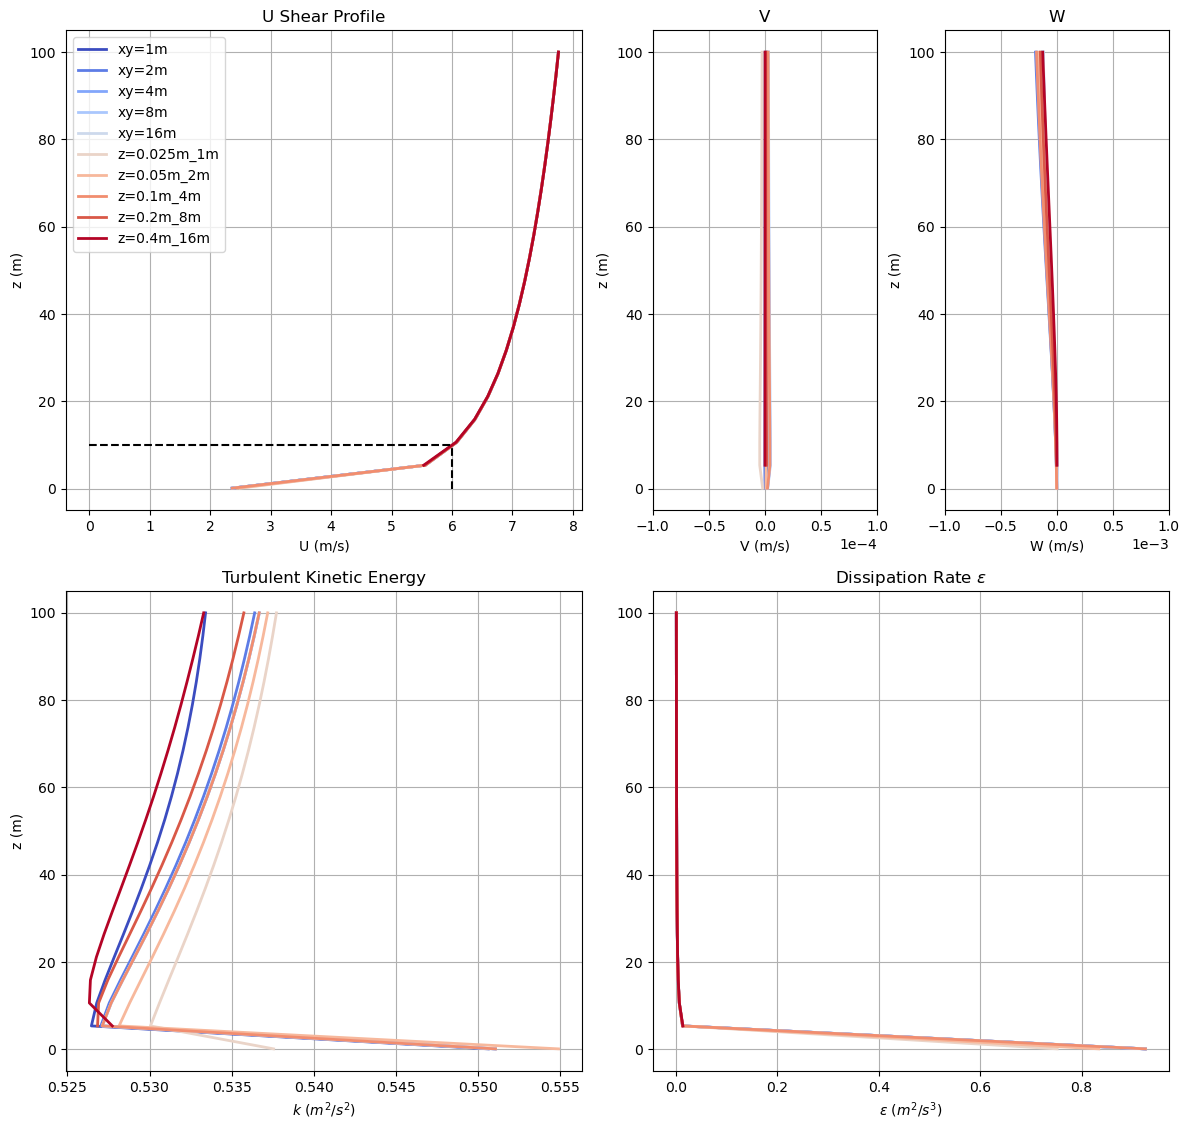

In [201]:
U_ref = 6      # [m/s]
wd = 0         # [deg]

# ---------------------------------------------------
# Uniform field
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

# ---------------------------------------------------
point = np.array([0, 0])   # x,y coordinates
z_vals = np.linspace(0.1, 100, 20)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(comb_lib_grid)))
# ---------------------------------------------------

fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Left column
ax_u = fig.add_subplot(gs[0, 0])
ax_k = fig.add_subplot(gs[1, 0], sharey=ax_u)

# Bottom-right
ax_eps = fig.add_subplot(gs[1, 1], sharey=ax_u)

# Split top-right into TWO COLUMNS
gs_right = gs[0, 1].subgridspec(1, 2, wspace=0.3)

ax_v = fig.add_subplot(gs_right[0], sharey=ax_u)
ax_w = fig.add_subplot(gs_right[1], sharey=ax_u)
ax_v.set_xlim(-1e-4, 1e-4)
ax_v.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax_w.set_xlim(-1e-3, 1e-3)
ax_w.ticklabel_format(style='sci', axis='x', scilimits=(0,0))


for xy, wf_current in comb_lib_grid.items():

    # Allocate arrays ONCE per wind field
    uwf = np.zeros(len(z_vals))
    vwf = np.zeros(len(z_vals))
    wwf = np.zeros(len(z_vals))
    kwf = np.zeros(len(z_vals))
    ewf = np.zeros(len(z_vals))

    # Fill arrays
    for i, z in enumerate(z_vals):

        vel, kwf[i], ewf[i] = wf_current.get_profile_at(
            x=point[0],
            y=point[1],
            z=z
        )

        uwf[i], vwf[i], wwf[i] = vel

    # Velocity magnitude
    Umag = np.sqrt(uwf**2 + vwf**2 + wwf**2)

    # =================================================
    # First row
    # U profile
    ax_u.plot(uwf, z_vals, linewidth=2, label=f'{xy}',color=colors[list(comb_lib_grid.keys()).index(xy)])

    # V profile
    ax_v.plot(vwf, z_vals, linewidth=2, color=colors[list(comb_lib_grid.keys()).index(xy)])

    # W profile
    ax_w.plot(wwf, z_vals, linewidth=2, color=colors[list(comb_lib_grid.keys()).index(xy)])

    # TKE
    ax_k.plot(kwf, z_vals, linewidth=2, color=colors[list(comb_lib_grid.keys()).index(xy)])

    # Dissipation
    ax_eps.plot(ewf, z_vals, linewidth=2, color=colors[list(comb_lib_grid.keys()).index(xy)])
# ---------------------------------------------------
# Labels and formatting

ax_u.plot([0, U_ref], [10, 10], color='k', linestyle='--')
ax_u.plot([U_ref, U_ref], [0,10], color='k', linestyle='--')

ax_u.set_title('U Shear Profile')
ax_u.set_xlabel('U (m/s)')
ax_u.set_ylabel('z (m)')
ax_u.legend()

ax_v.set_title('V')
ax_v.set_xlabel('V (m/s)')
ax_v.set_ylabel('z (m)')

ax_w.set_title('W')
ax_w.set_xlabel('W (m/s)')
ax_w.set_ylabel('z (m)')

ax_k.set_title('Turbulent Kinetic Energy')
ax_k.set_xlabel(r'$k$ ($m^2/s^2$)')
ax_k.set_ylabel('z (m)')

ax_eps.set_title(r'Dissipation Rate $\varepsilon$')
ax_eps.set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')

for ax in [ax_u, ax_v, ax_w, ax_k, ax_eps]:
    ax.grid(True)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

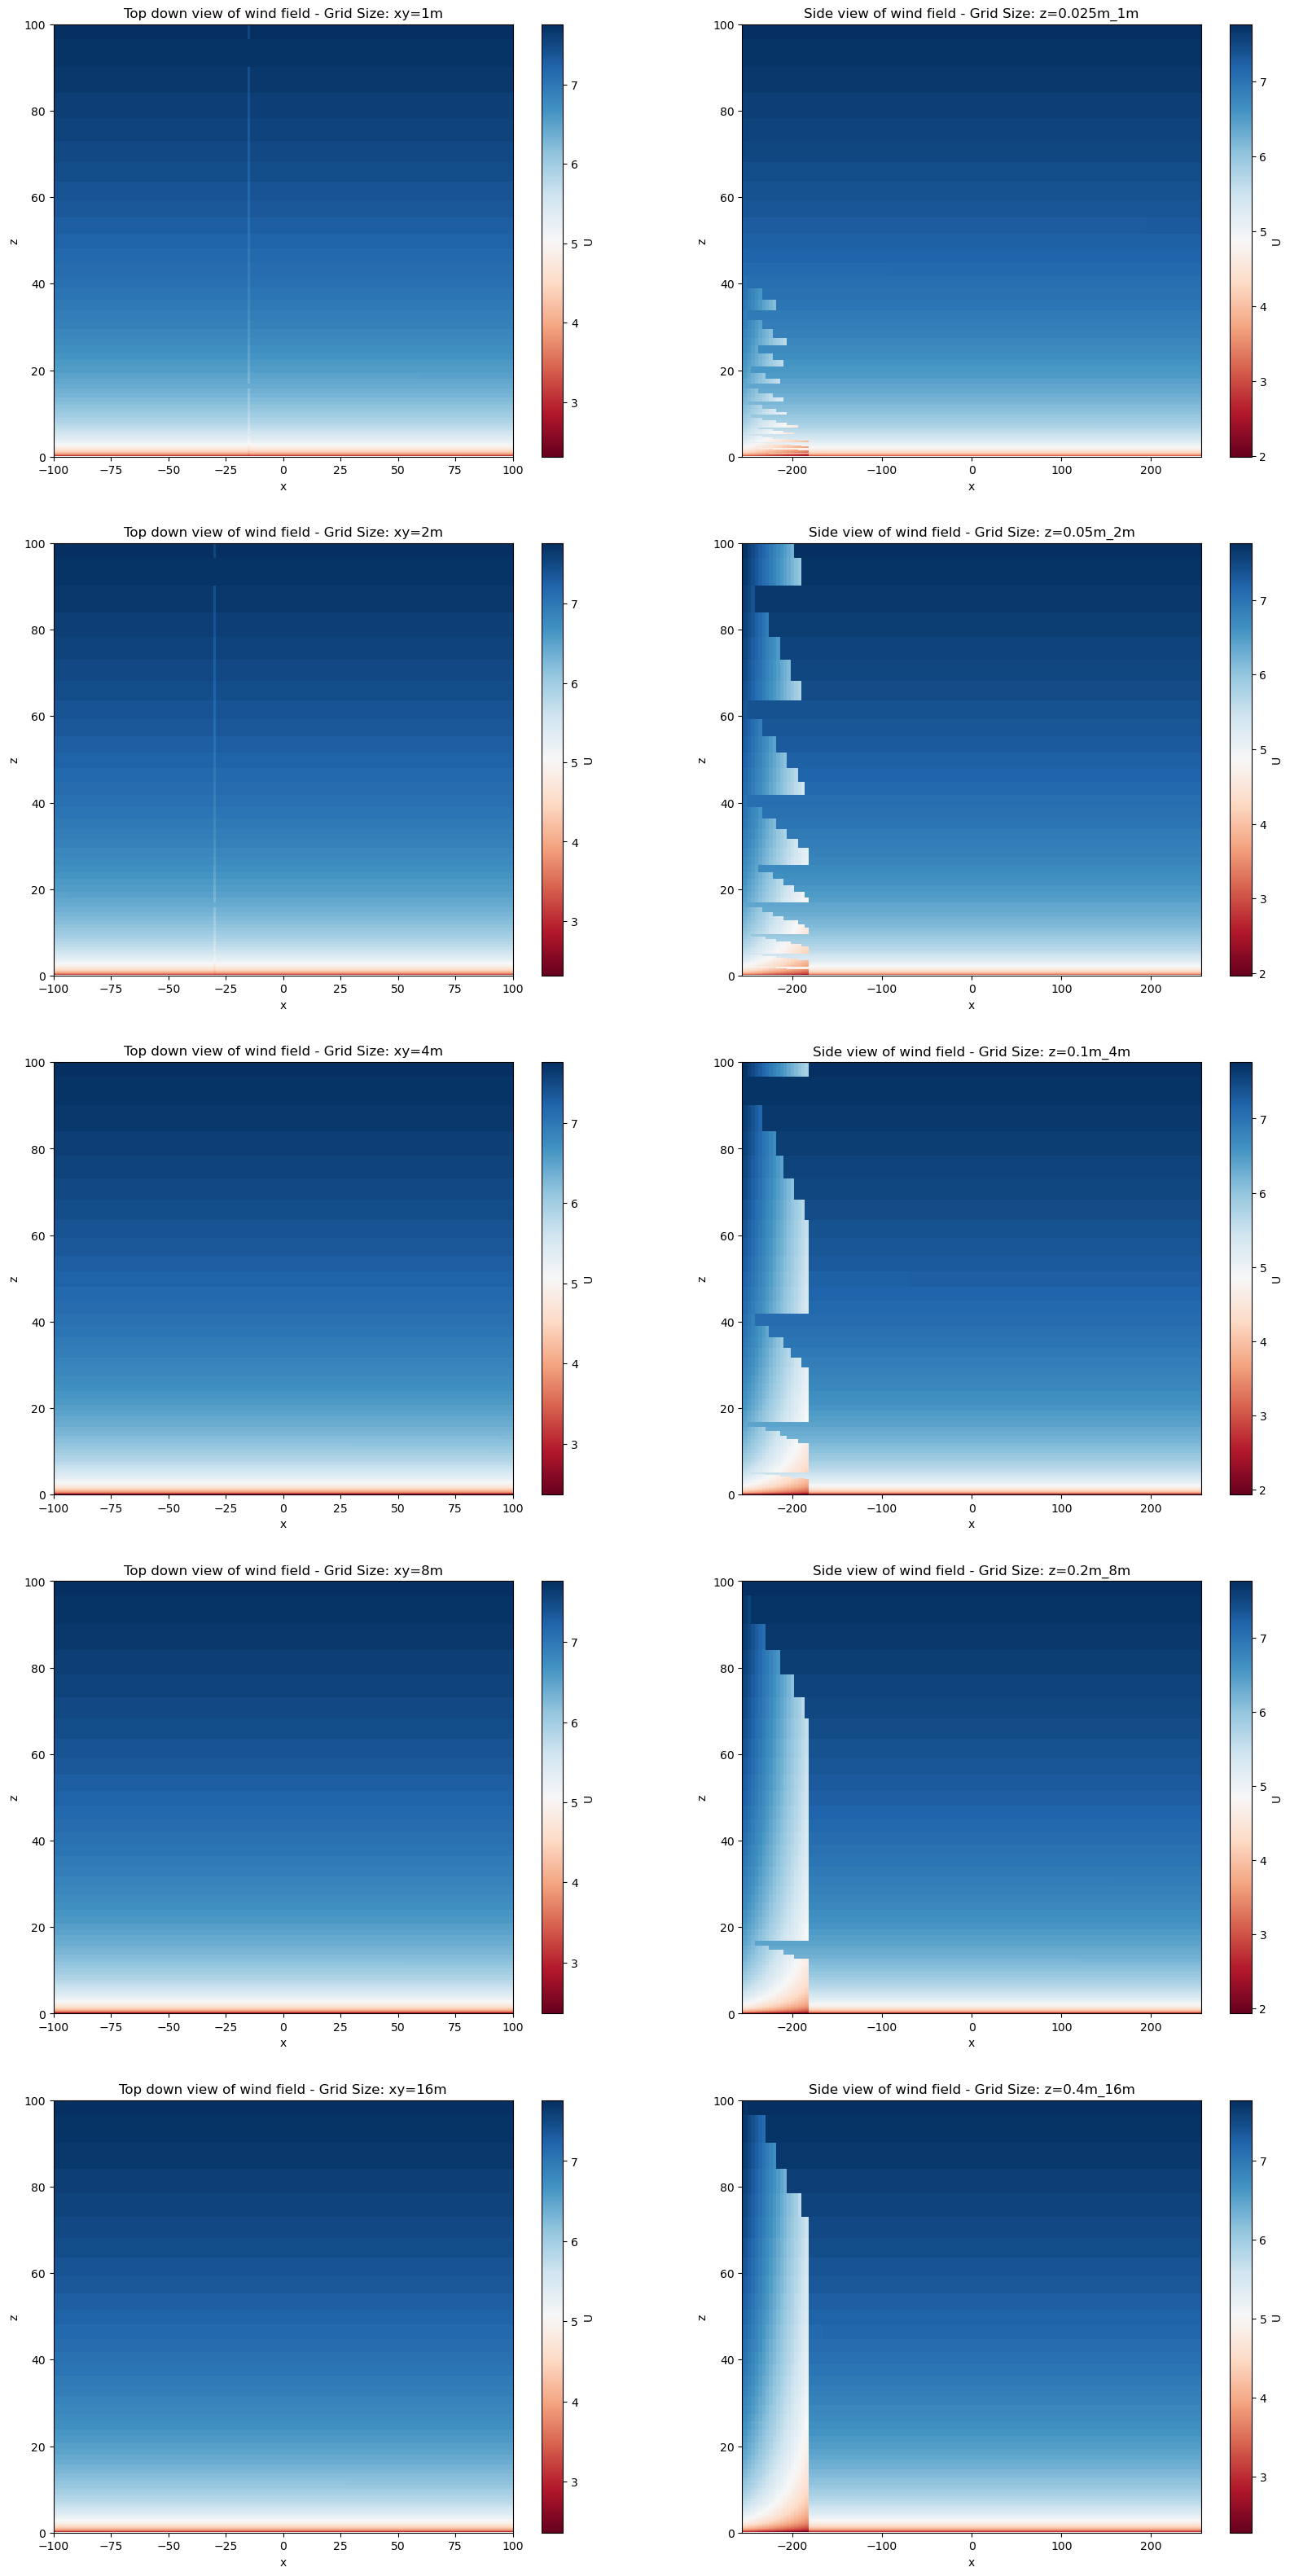

In [192]:
fig, ax = plt.subplots(5, 2, figsize=(20, 40))

# left column: xy grid fidelity heatplot
for i in range(len(xy_list)):
    U_slice = xy_wf_library_grid[xy_list[i]].ds.U.isel(y=4)

    U_slice.plot(
        x="x",
        y="z",
        ax=ax[i,0],
        cmap="RdBu",
    #    vmin=6.0,
    #    vmax=6.2
    )

    ax[i,0].set_xlim(-100, 100)
    ax[i,0].set_ylim(0, 100)
    ax[i,0].set_title(f'Top down view of wind field - Grid Size: {xy_list[i]}')

# right column: z grid fidelity heatplot
for i in range(len(z_list)):
    U_slice = z_wf_library_grid[z_list[i]].ds.U.isel(y=64) 

    U_slice.plot(
        x="x",
        y="z",
        ax=ax[i,1],
        cmap="RdBu",
    )

    ax[i,1].set_xlim(-256, 256)
    ax[i,1].set_ylim(0, 100)
    ax[i,1].set_title(f'Side view of wind field - Grid Size: {z_list[i]}')

plt.show()